# Rotating Amorphous Dipole — 2D FDTD Radiation Study (Version 4)

**Author:** Joshua Clavecillas  
**Version:** 4 (cleaned, improved, partial quantitative validation)  
**Date:** April 2026

---

## Project Goal

Simulate electromagnetic radiation from a **rotating amorphous dipole** source using a 2D TMz-style FDTD-like Maxwell solver. Validate the radiation using:

- Dipole moment tracking  
- Field snapshots  
- Poynting vector flow  
- Ring flux vs time  
- Angular intensity pattern  
- Wave speed measurement  
- Resolution convergence test  
- Frequency scaling study  

This notebook is designed to run **top-to-bottom** on a laptop in a reasonable time. Heavy parameter sweeps are guarded behind optional flags.

## Section 1 — Physical Model and Limitations

### Physical Model

A **rotating amorphous dipole** is a charge distribution consisting of two opposite-sign Gaussian blobs whose centers orbit the origin at angular velocity $\omega$. As the charge distribution rotates, it drives time-varying current densities $J_x, J_y$, which in turn radiate electromagnetic energy.

The electromagnetic fields $(E_x, E_y, B_z)$ are evolved using the **2D TMz Maxwell equations**:

$$\frac{\partial B_z}{\partial t} = -\left(\frac{\partial E_y}{\partial x} - \frac{\partial E_x}{\partial y}\right)$$

$$\frac{\partial E_x}{\partial t} = c^2 \frac{\partial B_z}{\partial y} - \frac{J_x}{\varepsilon_0}$$

$$\frac{\partial E_y}{\partial t} = -c^2 \frac{\partial B_z}{\partial x} - \frac{J_y}{\varepsilon_0}$$

### Honest Limitations

| Limitation | Impact |
|---|---|
| **2D geometry, not 3D** | Field structure and radiation patterns differ from 3D; $\omega^4$ law does not apply exactly |
| **Collocated grid** | All fields on same grid points; not a staggered Yee lattice; dispersion is worse |
| **Prescribed source** | $\rho$ and $J$ are set analytically; not self-consistent charge dynamics |
| **Gauss's law not enforced** | $\nabla \cdot E \neq \rho/\varepsilon_0$ exactly; reported as diagnostic |
| **Mur ABC + damping layer** | Not a perfect PML; reflections possible from boundaries |
| **Finite source size** | Near-field effects, finite wavelength-to-source-size ratio |
| **Finite domain** | Boundary reflections contaminate late-time results |

This simulation is best described as a **qualitative-to-semiquantitative 2D FDTD-like model**, not a quantitatively exact 3D dipole radiation solver.

## Section 2 — Numerical Method

### TMz FDTD-Like Update (Collocated Grid)

This notebook uses a **2D TMz-style collocated-grid Maxwell solver**. All three field components $(E_x, E_y, B_z)$ are stored at the **same grid points** (not staggered as in a proper Yee lattice). This simplifies the implementation at the cost of slightly worse numerical dispersion.

The time-stepping is a simple **forward Euler** / **leapfrog-style** scheme:

1. Update $B_z$ using the curl of $E$  
2. Update $E_x$, $E_y$ using the curl of $B_z$ and injected sources  
3. Apply absorbing boundary conditions (Mur ABC + damping layer)

### CFL Stability Condition

For a 2D wave equation on a square grid ($\Delta x = \Delta y$), the CFL stability condition is:

$$\text{CFL} = \frac{c \, \Delta t}{\Delta x} \leq \frac{1}{\sqrt{2}} \approx 0.707$$

We use `cfl_safety = 0.38` for a comfortable safety margin.

### Boundary Conditions

- **Mur first-order ABC**: applied at all four edges to absorb outgoing waves  
- **Absorbing damping layer**: a smooth mask $\sigma(x,y) \in [0,1]$ applied multiplicatively to fields near the boundary each timestep — a simple approximation, not a full PML

## Section 3 — Imports, Grid, Constants, and CFL Settings

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import json
from pathlib import Path
from IPython.display import display
import pandas as pd

# ── Normalized units ────────────────────────────────────────────────────────
epsilon0 = 1.0
mu0      = 1.0
c        = 1.0

np.set_printoptions(precision=6, suppress=True)

# ── Main simulation grid ─────────────────────────────────────────────────────
# Larger grids (e.g., 400x400) improve accuracy and reduce numerical dispersion
# but increase compute time roughly as O(N^2 * nsteps). 260x260 is a reasonable
# default for a laptop with ~1–3 min runtime.
Nx_main  = 800
Ny_main  = 800
Lx_main  = 7.0
Ly_main  = 7.0

dx_main  = Lx_main / Nx_main
dy_main  = Ly_main / Ny_main

cfl_safety = 0.5
dt_main    = cfl_safety * min(dx_main, dy_main) / c

cfl_number   = c * dt_main / dx_main
cfl_limit_2d = 1.0 / np.sqrt(2.0)
assert cfl_number <= cfl_limit_2d, f"CFL violated: {cfl_number:.4f} > {cfl_limit_2d:.4f}"

# Build grid arrays
x_main = np.linspace(-Lx_main/2, Lx_main/2, Nx_main, endpoint=False)
y_main = np.linspace(-Ly_main/2, Ly_main/2, Ny_main, endpoint=False)
X_main, Y_main = np.meshgrid(x_main, y_main, indexing='xy')

print("── Grid & CFL Summary ─────────────────────────────────")
print(f"  Nx_main = {Nx_main}, Ny_main = {Ny_main}")
print(f"  Lx_main = {Lx_main}, Ly_main = {Ly_main}")
print(f"  dx_main = {dx_main:.6f}, dy_main = {dy_main:.6f}")
print(f"  dt_main = {dt_main:.6f}")
print(f"  CFL     = {cfl_number:.4f}  (limit ≤ {cfl_limit_2d:.4f})  ✓ stable")
print("───────────────────────────────────────────────────────")

── Grid & CFL Summary ─────────────────────────────────
  Nx_main = 800, Ny_main = 800
  Lx_main = 7.0, Ly_main = 7.0
  dx_main = 0.008750, dy_main = 0.008750
  dt_main = 0.004375
  CFL     = 0.5000  (limit ≤ 0.7071)  ✓ stable
───────────────────────────────────────────────────────


## Section 4 — Source Construction: Rotating Amorphous Dipole

The charge density $\rho(x,y,t)$ consists of two **smooth Gaussian blobs** with opposite sign. Their centers rotate counter-clockwise at angular velocity $\omega$:

$$\mathbf{r}_{\pm}(t) = \pm\frac{d}{2}\begin{pmatrix}\cos(\omega t)\\\sin(\omega t)\end{pmatrix}$$

Each blob is slightly *amorphous* — a small angular distortion is added to make the source non-trivially shaped while remaining well-behaved. The blobs are normalized so that total charge is exactly zero at all times.

Source type      : amorphous
Net charge at t=0: 3.04e-16  (should be ~0)


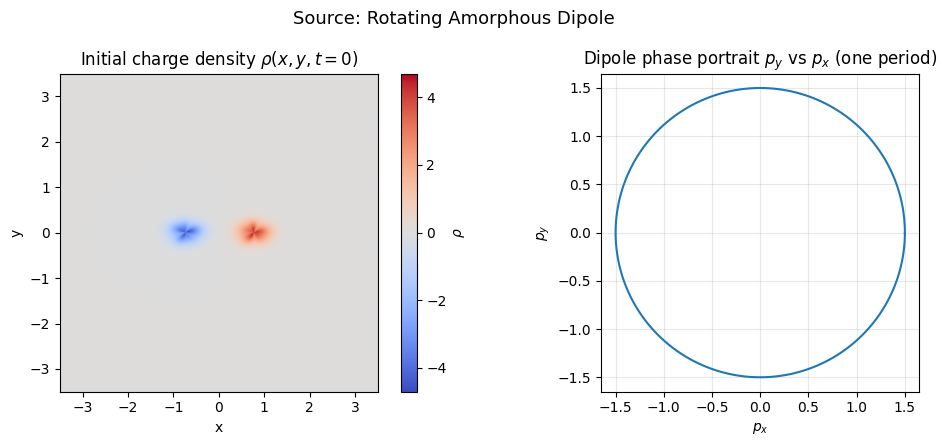

In [34]:
# ── Source parameters (shared across all sections) ───────────────────────────
omega_main  = 2.0    # angular frequency of rotation
Q_main      = 1.0   # charge magnitude
sep_main    = 1.5   # separation between charge centers
a_main      = 0.35  # Gaussian semi-axis x  (amorphous blob)
b_main      = 0.24  # Gaussian semi-axis y  (amorphous blob)
phase_main  = 0.6   # amorphous phase offset

r_obs_main  = 3.0   # observation ring radius
periods_main = 5.0  # number of rotation periods to simulate

# ── Source type selector ──────────────────────────────────────────────────────
# Options:
#   'amorphous'  – elliptical Gaussian blobs with angular distortion (original)
#   'circular'   – N point charges (narrow Gaussians) arranged on a ring;
#                  alternating +/- signs so net charge = 0
SOURCE_TYPE   = 'amorphous'   # <-- change to 'circular' to switch
N_ring        = 2             # number of charges on the ring (circular mode; must be even)
ring_radius   = sep_main / 2  # radius of the charge ring (circular mode)
sigma_pt      = 0.08          # width of each point-charge Gaussian (circular mode)

# ── Source functions ──────────────────────────────────────────────────────────
def amorphous_blob(X, Y, x0, y0, a, b, amplitude=0.001, phase=0.0):
    """Slightly amorphous Gaussian charge blob."""
    theta = np.arctan2(Y - y0, X - x0)
    distortion = 1.0 + 0.15 * np.cos(3.0 * theta + phase) + 0.10 * np.sin(5.0 * theta)
    envelope   = np.exp(-(((X - x0)**2) / a**2 + ((Y - y0)**2) / b**2))
    return amplitude * envelope * distortion


def circular_ring_rho(X, Y, angle, Q, ring_r, sigma, N, dx, dy):
    """
    N point charges (approximated as narrow Gaussians) evenly spaced on a
    ring of radius `ring_r`, rotating by `angle`.  Charges alternate +Q / -Q
    so the net charge is exactly zero.
    """
    rho = np.zeros_like(X)
    charges = []
    for k in range(N):
        phi  = angle + 2 * np.pi * k / N
        xk   = ring_r * np.cos(phi)
        yk   = ring_r * np.sin(phi)
        sign = +1 if k % 2 == 0 else -1
        blob = np.exp(-((X - xk)**2 + (Y - yk)**2) / (2 * sigma**2))
        charges.append((blob, sign))

    # Normalise each blob to carry exactly ±Q
    for blob, sign in charges:
        q_raw = np.sum(blob) * dx * dy
        if q_raw > 0:
            rho += sign * blob * (Q / q_raw)
    return rho


def rotating_rho(X, Y, t, omega, Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6,
                 dx=1.0, dy=1.0, source_type='amorphous',
                 n_ring=8, ring_r=None, sigma_pt=0.08):
    """
    Charge density dispatcher.

    source_type='amorphous'  → counter-clockwise rotating elliptical blob pair
    source_type='circular'   → N-charge ring rotating CCW (alternating ±Q)
    """
    angle = omega * t

    if source_type == 'circular':
        if ring_r is None:
            ring_r = sep / 2
        rho_total = circular_ring_rho(X, Y, angle, Q, ring_r, sigma_pt, n_ring, dx, dy)
        # Split into positive and negative parts for diagnostics
        rho_pos = np.where(rho_total > 0, rho_total, 0.0)
        rho_neg = np.where(rho_total < 0, rho_total, 0.0)
        return rho_total, rho_pos, rho_neg

    # --- default: amorphous dipole ---
    ca, sa = np.cos(angle), np.sin(angle)
    x_rot = X * ca + Y * sa
    y_rot = -X * sa + Y * ca

    rho_pos_raw = amorphous_blob(x_rot, y_rot, +sep/2, 0.0, a, b, amplitude=+1.0, phase=+phase)
    rho_neg_raw = amorphous_blob(x_rot, y_rot, -sep/2, 0.0, a, b, amplitude=+1.0, phase=-phase)

    q_pos = np.sum(rho_pos_raw) * dx * dy
    q_neg = np.sum(rho_neg_raw) * dx * dy

    rho_pos = rho_pos_raw * ( Q / q_pos)
    rho_neg = rho_neg_raw * (-Q / q_neg)
    return rho_pos + rho_neg, rho_pos, rho_neg


def compute_dipole_moment(rho, X, Y, dx, dy):
    """First moment of charge density = dipole moment."""
    px = np.sum(X * rho) * dx * dy
    py = np.sum(Y * rho) * dx * dy
    return px, py


# ── Plot initial charge density ───────────────────────────────────────────────
rho0, rho_p0, rho_n0 = rotating_rho(
    X_main, Y_main, t=0.0, omega=omega_main,
    Q=Q_main, sep=sep_main, a=a_main, b=b_main, phase=phase_main,
    dx=dx_main, dy=dy_main,
    source_type=SOURCE_TYPE, n_ring=N_ring, ring_r=ring_radius, sigma_pt=sigma_pt
)

print(f"Source type      : {SOURCE_TYPE}")
print(f"Net charge at t=0: {np.sum(rho0)*dx_main*dy_main:.2e}  (should be ~0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmax = np.abs(rho0).max()
im0 = axes[0].imshow(rho0, origin='lower', cmap='coolwarm', vmin=-vmax, vmax=vmax,
                     extent=[-Lx_main/2, Lx_main/2, -Ly_main/2, Ly_main/2])
plt.colorbar(im0, ax=axes[0], fraction=0.046, label=r'$\rho$')
axes[0].set_title('Initial charge density $\\rho(x,y,t=0)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Phase portrait of dipole moment over one period
T_main = 2.0 * np.pi / omega_main
t_demo = np.linspace(0, T_main, 200)
px_demo, py_demo = [], []
for td in t_demo:
    rho_td, *_ = rotating_rho(X_main, Y_main, t=td, omega=omega_main,
                               Q=Q_main, sep=sep_main, a=a_main, b=b_main, phase=phase_main,
                               dx=dx_main, dy=dy_main,
                               source_type=SOURCE_TYPE, n_ring=N_ring,
                               ring_r=ring_radius, sigma_pt=sigma_pt)
    pxd, pyd = compute_dipole_moment(rho_td, X_main, Y_main, dx_main, dy_main)
    px_demo.append(pxd); py_demo.append(pyd)

axes[1].plot(px_demo, py_demo, lw=1.5, color='tab:blue')
axes[1].set_aspect('equal')
axes[1].set_title('Dipole phase portrait $p_y$ vs $p_x$ (one period)')
axes[1].set_xlabel('$p_x$'); axes[1].set_ylabel('$p_y$')
axes[1].grid(alpha=0.3)

src_label = 'Rotating Amorphous Dipole' if SOURCE_TYPE == 'amorphous' \
    else f'Circular Ring ({N_ring} charges, r={ring_radius})'
plt.suptitle(f'Source: {src_label}', fontsize=13)
plt.tight_layout()
plt.show()


## Section 5 — Current Density and Continuity Check

The current density of a rigidly rotating charge distribution is:

$$J_x = \rho \cdot v_x = \rho \cdot (-\omega y), \quad J_y = \rho \cdot v_y = \rho \cdot (+\omega x)$$

**Continuity diagnostic:** We check $\partial_t \rho + \nabla \cdot \mathbf{J} \approx 0$ using centered finite differences. The normalized residual measures how well the prescribed source satisfies local charge conservation.

In [35]:
# ── Finite-difference helpers ─────────────────────────────────────────────────
def ddx(F, dx):
    """Centered finite difference in x (non-periodic, one-sided at edges)."""
    dF = np.empty_like(F)
    dF[:, 1:-1] = (F[:, 2:] - F[:, :-2]) / (2*dx)
    dF[:, 0]    = (F[:, 1] - F[:, 0]) / dx
    dF[:, -1]   = (F[:, -1] - F[:, -2]) / dx
    return dF


def ddy(F, dy):
    """Centered finite difference in y (non-periodic, one-sided at edges)."""
    dF = np.empty_like(F)
    dF[1:-1, :] = (F[2:, :] - F[:-2, :]) / (2*dy)
    dF[0, :]    = (F[1, :] - F[0, :]) / dy
    dF[-1, :]   = (F[-1, :] - F[-2, :]) / dy
    return dF


def divergence2d(Fx, Fy, dx, dy):
    return ddx(Fx, dx) + ddy(Fy, dy)


# ── Current density ───────────────────────────────────────────────────────────
def compute_current(rho, X, Y, omega):
    """Rigid rotation current: J = rho * v, v = omega x r_perp."""
    Jx = rho * (-omega * Y)
    Jy = rho * ( omega * X)
    return Jx, Jy


# ── Continuity residual at a single time ─────────────────────────────────────
def continuity_residual(X, Y, t, dt, omega, Q, sep, a, b, phase, dx, dy):
    """Returns (residual_rms, normalized_residual_rms)."""
    rho_p, *_ = rotating_rho(X, Y, t-dt, omega, Q, sep, a, b, phase, dx, dy)
    rho_0, *_ = rotating_rho(X, Y, t,    omega, Q, sep, a, b, phase, dx, dy)
    rho_n, *_ = rotating_rho(X, Y, t+dt, omega, Q, sep, a, b, phase, dx, dy)

    Jx, Jy = compute_current(rho_0, X, Y, omega)
    drho_dt = (rho_n - rho_p) / (2.0 * dt)
    divJ    = divergence2d(Jx, Jy, dx, dy)
    residual = drho_dt + divJ

    core = (slice(2, -2), slice(2, -2))
    rms  = np.sqrt(np.mean(residual[core]**2))
    denom = (np.sqrt(np.mean(drho_dt[core]**2))
             + np.sqrt(np.mean(divJ[core]**2)) + 1e-15)
    return rms, rms / denom


# ── Demo: check continuity at t=0 ────────────────────────────────────────────
rms0, norm0 = continuity_residual(
    X_main, Y_main, t=0.5*T_main, dt=dt_main,
    omega=omega_main, Q=Q_main, sep=sep_main, a=a_main, b=b_main,
    phase=phase_main, dx=dx_main, dy=dy_main
)
print(f"Continuity residual at t=T/2: RMS = {rms0:.4e}, normalized = {norm0:.4e}")
print("A normalized value ≪ 1 means ∂ρ/∂t ≈ -∇·J is well satisfied.")

Continuity residual at t=T/2: RMS = 3.4575e-01, normalized = 7.5277e-02
A normalized value ≪ 1 means ∂ρ/∂t ≈ -∇·J is well satisfied.


## Section 6 — FDTD Solver (TMz-Style Update)

> **Note:** This is a **2D FDTD-like collocated-grid Maxwell solver**, not a full staggered Yee implementation.  
> All fields $(E_x, E_y, B_z)$ are stored on the same grid points.

The update loop per timestep:
1. $B_z^{n+1} = B_z^n - \Delta t \left(\partial_x E_y^n - \partial_y E_x^n\right)$  
2. $E_x^{n+1} = E_x^n + \Delta t \left(c^2 \partial_y B_z^{n+1} - J_x^n / \varepsilon_0\right)$  
3. $E_y^{n+1} = E_y^n + \Delta t \left(-c^2 \partial_x B_z^{n+1} - J_y^n / \varepsilon_0\right)$  
4. Apply Mur ABC + absorbing mask to all three fields

## Section 7 — Absorbing Boundary Conditions

We combine two approaches:
1. **Mur first-order ABC** at the four edges — a wave-equation-based absorbing condition  
2. **Smooth damping mask** — multiplies fields by a value close to 1 in the interior that gradually decreases to `1 - strength` near the boundary over a width of `abs_width` grid lengths

The mask is **not a PML** (Perfectly Matched Layer). It is a simple multiplicative damping approximation that suppresses reflections without the complexity of a full PML formulation.

The cell below defines all boundary and solver infrastructure.

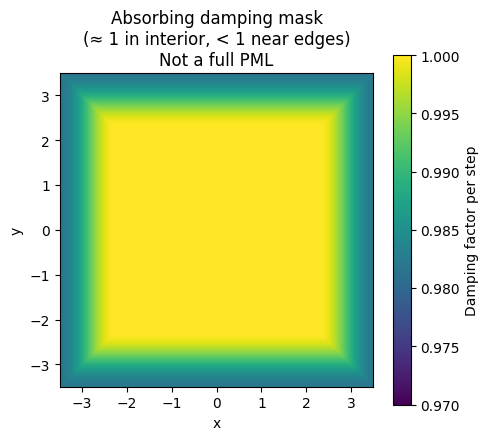

Mask interior min: 0.982273, edge min: 0.982000


In [36]:
# ── Absorbing damping mask ────────────────────────────────────────────────────
def make_absorbing_mask(X, Y, Lx, Ly, width=1.0, strength=0.015):
    """
    Smooth damping mask: 1.0 in the interior, gradually smaller near boundaries.
    This is a simple approximation, NOT a perfect PML.

    Parameters
    ----------
    width    : physical width of the absorbing layer
    strength : max damping per step (small positive, e.g. 0.015)
    """
    dist_left   = X + Lx/2
    dist_right  = Lx/2 - X
    dist_bottom = Y + Ly/2
    dist_top    = Ly/2 - Y

    dist_edge = np.minimum(
        np.minimum(dist_left, dist_right),
        np.minimum(dist_bottom, dist_top)
    )
    s = np.clip(dist_edge / width, 0.0, 1.0)
    # smoothstep profile: 0 at edge → 1 in interior
    smooth = s * s * (3.0 - 2.0 * s)
    mask = 1.0 - strength * (1.0 - smooth)
    return np.clip(mask, 0.0, 1.0)


# ── Mur first-order ABC ───────────────────────────────────────────────────────
def apply_mur_abc(u, u_prev, c, dt, dx, dy):
    """First-order Mur absorbing boundary condition for a 2D scalar field."""
    u_new = u.copy()
    cx = (c*dt - dx) / (c*dt + dx)
    cy = (c*dt - dy) / (c*dt + dy)
    u_new[:, 0]  = u_prev[:, 1]  + cx * (u[:, 1]  - u_prev[:, 0])
    u_new[:, -1] = u_prev[:, -2] + cx * (u[:, -2] - u_prev[:, -1])
    u_new[0, :]  = u_prev[1, :]  + cy * (u[1, :]  - u_prev[0, :])
    u_new[-1, :] = u_prev[-2, :] + cy * (u[-2, :] - u_prev[-1, :])
    return u_new


# ── Poynting vector ───────────────────────────────────────────────────────────
def compute_poynting(Ex, Ey, Bz, mu0=1.0):
    Sx =  Ey * Bz / mu0
    Sy = -Ex * Bz / mu0
    return Sx, Sy


# ── Ring flux measurement ─────────────────────────────────────────────────────
def measure_flux_ring(Sx, Sy, X, Y, r_obs=3.2, ntheta=240):
    """Compute radial Poynting flux around a circle of radius r_obs."""
    theta  = np.linspace(0, 2*np.pi, ntheta, endpoint=False)
    dtheta = 2*np.pi / ntheta
    xr = r_obs * np.cos(theta)
    yr = r_obs * np.sin(theta)

    x_vals = X[0, :]
    y_vals = Y[:, 0]

    ix = np.clip(np.searchsorted(x_vals, xr), 1, len(x_vals)-1)
    iy = np.clip(np.searchsorted(y_vals, yr), 1, len(y_vals)-1)
    ix = np.where(np.abs(x_vals[ix-1] - xr) < np.abs(x_vals[ix] - xr), ix-1, ix)
    iy = np.where(np.abs(y_vals[iy-1] - yr) < np.abs(y_vals[iy] - yr), iy-1, iy)

    Sr       = Sx[iy, ix] * np.cos(theta) + Sy[iy, ix] * np.sin(theta)
    intensity = np.maximum(Sr, 0.0)
    signed_power  = r_obs * np.sum(Sr) * dtheta
    outward_power = r_obs * np.sum(intensity) * dtheta
    return theta, Sr, intensity, dtheta, signed_power, outward_power


# ── Visualize absorbing mask ──────────────────────────────────────────────────
abs_mask_main = make_absorbing_mask(X_main, Y_main, Lx_main, Ly_main,
                                     width=1.2, strength=0.018)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(abs_mask_main, origin='lower', cmap='viridis', vmin=0.97, vmax=1.0,
               extent=[-Lx_main/2, Lx_main/2, -Ly_main/2, Ly_main/2])
plt.colorbar(im, ax=ax, label='Damping factor per step')
ax.set_title('Absorbing damping mask\n(≈ 1 in interior, < 1 near edges)\nNot a full PML')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()
print(f"Mask interior min: {abs_mask_main[10:-10,10:-10].min():.6f}, edge min: {abs_mask_main.min():.6f}")

In [37]:
# ── Core FDTD runner ──────────────────────────────────────────────────────────
def run_fdtd(
    X, Y, dx, dy, dt,
    nsteps=1400, omega=2.0,
    Q=1.0, sep=1.0, a=0.35, b=0.24, phase=0.6,
    r_obs=3.2, ntheta_ring=180,
    save_interval=10, store_frames=True,
    continuity_interval=120,
    extra_r_obs=None,           # optional second ring radius for wave-speed test
    abs_width=1.2, abs_strength=0.018,
    progress_ticks=False, label='FDTD',
):
    """
    2D TMz collocated-grid FDTD solver with:
      - Source injection (Jx, Jy from rotating dipole)
      - Mur first-order ABC at all edges
      - Smooth absorbing damping mask (not a PML)
      - Ring flux diagnostics
      - Gauss-law and continuity diagnostics (sampled)
      - Optional frame storage

    Returns a dict with all time series and final fields.
    """
    Ny_loc, Nx_loc = X.shape
    Ex = np.zeros((Ny_loc, Nx_loc))
    Ey = np.zeros((Ny_loc, Nx_loc))
    Bz = np.zeros((Ny_loc, Nx_loc))

    cfl_ratio = c * dt / dx
    cfl_lim   = 1.0 / np.sqrt(2.0)
    if cfl_ratio > cfl_lim + 1e-8:
        raise ValueError(f'CFL violated: {cfl_ratio:.4f} > {cfl_lim:.4f}')

    # Absorbing mask (same for all three fields)
    Lx_loc = dx * Nx_loc
    Ly_loc = dy * Ny_loc
    mask = make_absorbing_mask(X, Y, Lx_loc, Ly_loc, width=abs_width, strength=abs_strength)

    t_arr       = np.arange(nsteps) * dt
    px_arr      = np.zeros(nsteps)
    py_arr      = np.zeros(nsteps)
    flux_signed = np.zeros(nsteps)
    flux_out    = np.zeros(nsteps)

    # Optional second ring
    flux_r2 = np.zeros(nsteps) if extra_r_obs is not None else None

    diag_t         = []
    cont_rms_list  = []
    cont_norm_list = []
    gauss_rms_list = []

    frames_Bz  = []
    frames_rho = []
    frames_Ex  = []
    frames_Ey  = []
    frame_steps = []

    tick_interval = max(1, nsteps // 40)
    t0 = time.perf_counter()
    if progress_ticks:
        print(f'{label}: ', end='', flush=True)

    rho = None  # will be set each loop

    for n in range(nsteps):
        t = t_arr[n]
        rho, _, _ = rotating_rho(X, Y, t=t, omega=omega, Q=Q,
                                  sep=sep, a=a, b=b, phase=phase, dx=dx, dy=dy)
        Jx, Jy = compute_current(rho, X, Y, omega)

        Ex_prev = Ex.copy()
        Ey_prev = Ey.copy()
        Bz_prev = Bz.copy()

        # ── TMz field update ─────────────────────────────────────────────────
        # Step 1: advance Bz
        curl_E = ddx(Ey, dx) - ddy(Ex, dy)
        Bz    -= dt * curl_E

        # Step 2: advance Ex, Ey using updated Bz
        Ex += dt * ( c**2 * ddy(Bz, dy) - Jx / epsilon0)
        Ey += dt * (-c**2 * ddx(Bz, dx) - Jy / epsilon0)

        # Step 3: Mur ABC
        Ex = apply_mur_abc(Ex, Ex_prev, c, dt, dx, dy)
        Ey = apply_mur_abc(Ey, Ey_prev, c, dt, dx, dy)
        Bz = apply_mur_abc(Bz, Bz_prev, c, dt, dx, dy)

        # Step 4: Absorbing damping mask
        Ex *= mask
        Ey *= mask
        Bz *= mask

        # ── Dipole moment ────────────────────────────────────────────────────
        px_arr[n], py_arr[n] = compute_dipole_moment(rho, X, Y, dx, dy)

        # ── Ring flux ─────────────────────────────────────────────────────────
        Sx, Sy = compute_poynting(Ex, Ey, Bz, mu0=mu0)
        _, _, _, _, fs, fo = measure_flux_ring(Sx, Sy, X, Y, r_obs=r_obs, ntheta=ntheta_ring)
        flux_signed[n] = fs
        flux_out[n]    = fo

        if extra_r_obs is not None:
            _, _, _, _, _, fo2 = measure_flux_ring(Sx, Sy, X, Y, r_obs=extra_r_obs, ntheta=ntheta_ring)
            flux_r2[n] = fo2

        # ── Diagnostics (sampled) ─────────────────────────────────────────────
        if n % continuity_interval == 0 and 0 < n < nsteps - 1:
            rho_p, *_ = rotating_rho(X, Y, t-dt, omega, Q, sep, a, b, phase, dx, dy)
            rho_n, *_ = rotating_rho(X, Y, t+dt, omega, Q, sep, a, b, phase, dx, dy)
            drho_dt   = (rho_n - rho_p) / (2.0 * dt)
            divJ      = divergence2d(Jx, Jy, dx, dy)
            residual  = drho_dt + divJ
            core      = (slice(2,-2), slice(2,-2))
            rms_c     = np.sqrt(np.mean(residual[core]**2))
            denom_c   = (np.sqrt(np.mean(drho_dt[core]**2))
                         + np.sqrt(np.mean(divJ[core]**2)) + 1e-15)
            cont_rms_list.append(rms_c)
            cont_norm_list.append(rms_c / denom_c)

            divE     = ddx(Ex, dx) + ddy(Ey, dy)
            gauss_r  = divE - rho / epsilon0
            gauss_rms_list.append(np.sqrt(np.mean(gauss_r[core]**2)))
            diag_t.append(t)

        # ── Frame storage ─────────────────────────────────────────────────────
        if store_frames and n % save_interval == 0:
            frames_Bz.append(Bz.copy())
            frames_rho.append(rho.copy())
            frames_Ex.append(Ex.copy())
            frames_Ey.append(Ey.copy())
            frame_steps.append(n)

        if progress_ticks and ((n+1) % tick_interval == 0 or (n+1) == nsteps):
            print('✓', end='', flush=True)

    elapsed = time.perf_counter() - t0
    if progress_ticks:
        print(f' done ({elapsed:.1f}s)')

    frame_steps_arr = np.array(frame_steps, dtype=int)
    return {
        't':             t_arr,
        'Ex': Ex, 'Ey': Ey, 'Bz': Bz,
        'rho_last':      rho,
        'px': px_arr, 'py': py_arr,
        'flux_signed':   flux_signed,
        'flux_out':      flux_out,
        'flux_r2':       flux_r2,
        'frames_Bz':     np.array(frames_Bz)  if frames_Bz  else np.empty((0,)),
        'frames_rho':    np.array(frames_rho) if frames_rho else np.empty((0,)),
        'frames_Ex':     np.array(frames_Ex)  if frames_Ex  else np.empty((0,)),
        'frames_Ey':     np.array(frames_Ey)  if frames_Ey  else np.empty((0,)),
        'frame_steps':   frame_steps_arr,
        'frame_t':       t_arr[frame_steps_arr] if len(frame_steps_arr) else np.array([]),
        'diag_t':        np.array(diag_t),
        'cont_rms':      np.array(cont_rms_list),
        'cont_norm':     np.array(cont_norm_list),
        'gauss_rms':     np.array(gauss_rms_list),
        'cfl_ratio':     cfl_ratio,
        'cfl_limit':     cfl_lim,
        'elapsed':       elapsed,
        'r_obs':         r_obs,
        'extra_r_obs':   extra_r_obs,
    }

print("run_fdtd() defined ✓")

run_fdtd() defined ✓


## Section 8 — Main Simulation Run

We run the primary simulation with:

| Parameter | Value |
|---|---|
| Grid | 260 × 260, $L = 10$ |
| $\omega$ | 2.0 |
| Periods | 5 |
| $r_\text{obs}$ | 3.2 |

Two observation rings are tracked simultaneously (at $r_1 = 2.5$ and $r_2 = 3.5$) for the wave speed validation in Section 13.

In [43]:
# ── Main simulation parameters ────────────────────────────────────────────────
T_main           = 2.0 * np.pi / omega_main
total_time_main  = periods_main * T_main + r_obs_main / c
nsteps_main      = int(np.ceil(total_time_main / dt_main))
save_int_main    = max(1, nsteps_main // 160)   # ~160 frames stored
cont_int_main    = max(1, nsteps_main // 100)   # ~100 diagnostic samples

print("── Main Simulation Parameters ─────────────────────────")
print(f"  omega_main    = {omega_main}")
print(f"  T_main        = {T_main:.4f}")
print(f"  periods_main  = {periods_main}")
print(f"  total_time    = {total_time_main:.4f}")
print(f"  nsteps_main   = {nsteps_main}")
print(f"  dt_main       = {dt_main:.6f}")
print(f"  CFL           = {c*dt_main/dx_main:.4f}")
print(f"  r_obs_main    = {r_obs_main}")
print(f"  save_interval = {save_int_main}")
print("───────────────────────────────────────────────────────")

# Run — also track a second ring at r=2.5 for wave-speed test
r_wave1 = 2.0
r_wave2 = 2.2

result_main = run_fdtd(
    X_main, Y_main, dx_main, dy_main, dt_main,
    nsteps      = nsteps_main,
    omega       = omega_main,
    Q=Q_main, sep=sep_main, a=a_main, b=b_main, phase=phase_main,
    r_obs       = r_obs_main,
    ntheta_ring = 360,
    save_interval      = save_int_main,
    store_frames       = True,
    continuity_interval= cont_int_main,
    extra_r_obs = r_wave2,   # second ring at r2=3.5 (r1=r_obs_main is used as r_wave1 proxy)
    abs_width   = 1.2,
    abs_strength= 0.018,
    progress_ticks = True,
    label = 'Main run',
)

# ── Summary statistics ────────────────────────────────────────────────────────
t_start_avg_main = r_obs_main / c + 2.0 * T_main
mask_avg = result_main['t'] >= t_start_avg_main
mean_flux_avg    = np.mean(result_main['flux_out'][mask_avg]) if mask_avg.any() else np.nan
std_flux_avg     = np.std( result_main['flux_out'][mask_avg]) if mask_avg.any() else np.nan
med_cont_norm    = np.nanmedian(result_main['cont_norm'])
med_gauss_rms    = np.nanmedian(result_main['gauss_rms'])

print("\n── Main Run Summary ────────────────────────────────────")
print(f"  Elapsed runtime      : {result_main['elapsed']:.1f} s")
print(f"  CFL ratio            : {result_main['cfl_ratio']:.4f}  (limit {result_main['cfl_limit']:.4f})")
print(f"  nsteps               : {nsteps_main}")
print(f"  Mean outward flux    : {mean_flux_avg:.4e}  (averaged after t = {t_start_avg_main:.2f})")
print(f"  Std  outward flux    : {std_flux_avg:.4e}")
print(f"  Median cont norm     : {med_cont_norm:.4e}")
print(f"  Median Gauss RMS     : {med_gauss_rms:.4e}")
print("───────────────────────────────────────────────────────")

── Main Simulation Parameters ─────────────────────────
  omega_main    = 2.0
  T_main        = 3.1416
  periods_main  = 5.0
  total_time    = 18.7080
  nsteps_main   = 4277
  dt_main       = 0.004375
  CFL           = 0.5000
  r_obs_main    = 3.0
  save_interval = 26
───────────────────────────────────────────────────────
Main run: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (122.4s)

── Main Run Summary ────────────────────────────────────
  Elapsed runtime      : 122.4 s
  CFL ratio            : 0.5000  (limit 0.7071)
  nsteps               : 4277
  Mean outward flux    : 2.3711e-01  (averaged after t = 9.28)
  Std  outward flux    : 3.2569e-02
  Median cont norm     : 9.3250e-02
  Median Gauss RMS     : 3.0258e-01
───────────────────────────────────────────────────────


## Section 9 — Dipole Moment Validation

The dipole moment $\mathbf{p}(t) = \int \mathbf{r}\,\rho \,dA$ should rotate as a circle in the $(p_x, p_y)$ plane at angular frequency $\omega_\text{main}$. We extract it directly from the tracked charge density.

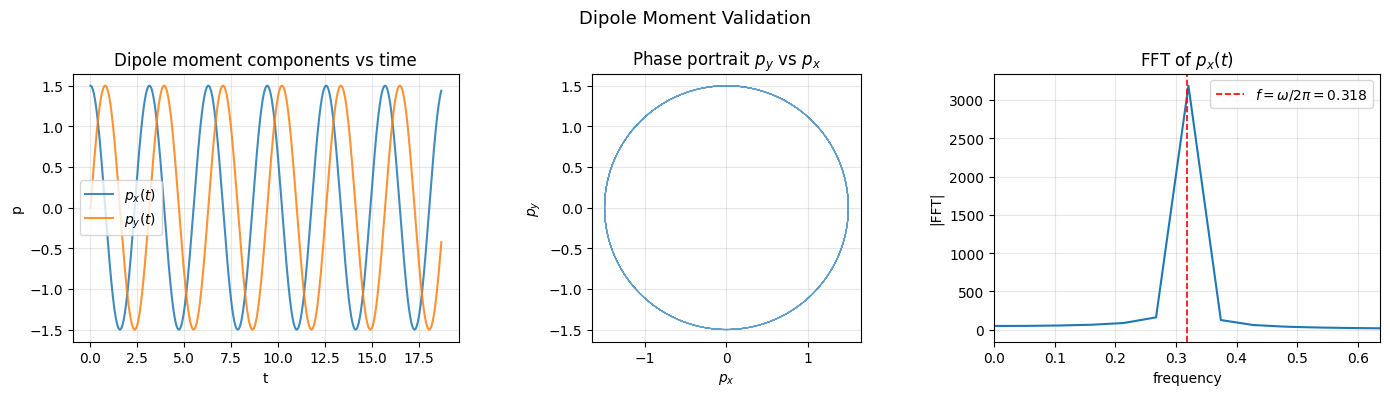

RMS dipole amplitude: 1.4947
Dominant FFT frequency: 0.3207  (expected 0.3183)


In [44]:
px_m = result_main['px']
py_m = result_main['py']
t_m  = result_main['t']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# px, py vs time
axes[0].plot(t_m, px_m, label='$p_x(t)$', alpha=0.85)
axes[0].plot(t_m, py_m, label='$p_y(t)$', alpha=0.85)
axes[0].set_title('Dipole moment components vs time')
axes[0].set_xlabel('t'); axes[0].set_ylabel('p')
axes[0].grid(alpha=0.3); axes[0].legend()

# Phase portrait
axes[1].plot(px_m, py_m, lw=0.8, alpha=0.7)
axes[1].set_aspect('equal')
axes[1].set_title('Phase portrait $p_y$ vs $p_x$')
axes[1].set_xlabel('$p_x$'); axes[1].set_ylabel('$p_y$')
axes[1].grid(alpha=0.3)

# Estimate amplitude and frequency via FFT
from numpy.fft import rfft, rfftfreq
N_fft   = len(px_m)
freqs   = rfftfreq(N_fft, d=dt_main)
pxfft   = np.abs(rfft(px_m))
peak_f  = freqs[np.argmax(pxfft[1:])+1]
amp_px  = np.sqrt(2) * np.std(px_m)   # RMS amplitude

axes[2].plot(freqs[:N_fft//4], pxfft[:N_fft//4])
axes[2].axvline(omega_main/(2*np.pi), color='r', ls='--', lw=1.2,
                label=f'$f = \\omega/2\\pi = {omega_main/(2*np.pi):.3f}$')
axes[2].set_title('FFT of $p_x(t)$')
axes[2].set_xlabel('frequency'); axes[2].set_ylabel('|FFT|')
axes[2].set_xlim(0, omega_main/np.pi)
axes[2].grid(alpha=0.3); axes[2].legend()

plt.suptitle('Dipole Moment Validation', fontsize=13)
plt.tight_layout()
plt.show()

print(f"RMS dipole amplitude: {amp_px:.4f}")
print(f"Dominant FFT frequency: {peak_f:.4f}  (expected {omega_main/(2*np.pi):.4f})")

## Section 10 — Field Snapshots

We show $B_z(x,y)$ and $|E|(x,y)$ at four timesteps:
1. **Early** — just after source turn-on
2. **Near arrival** — around $t \approx r_\text{obs}/c$
3. **Later radiation** — established wavefronts
4. **Final step** — end of simulation

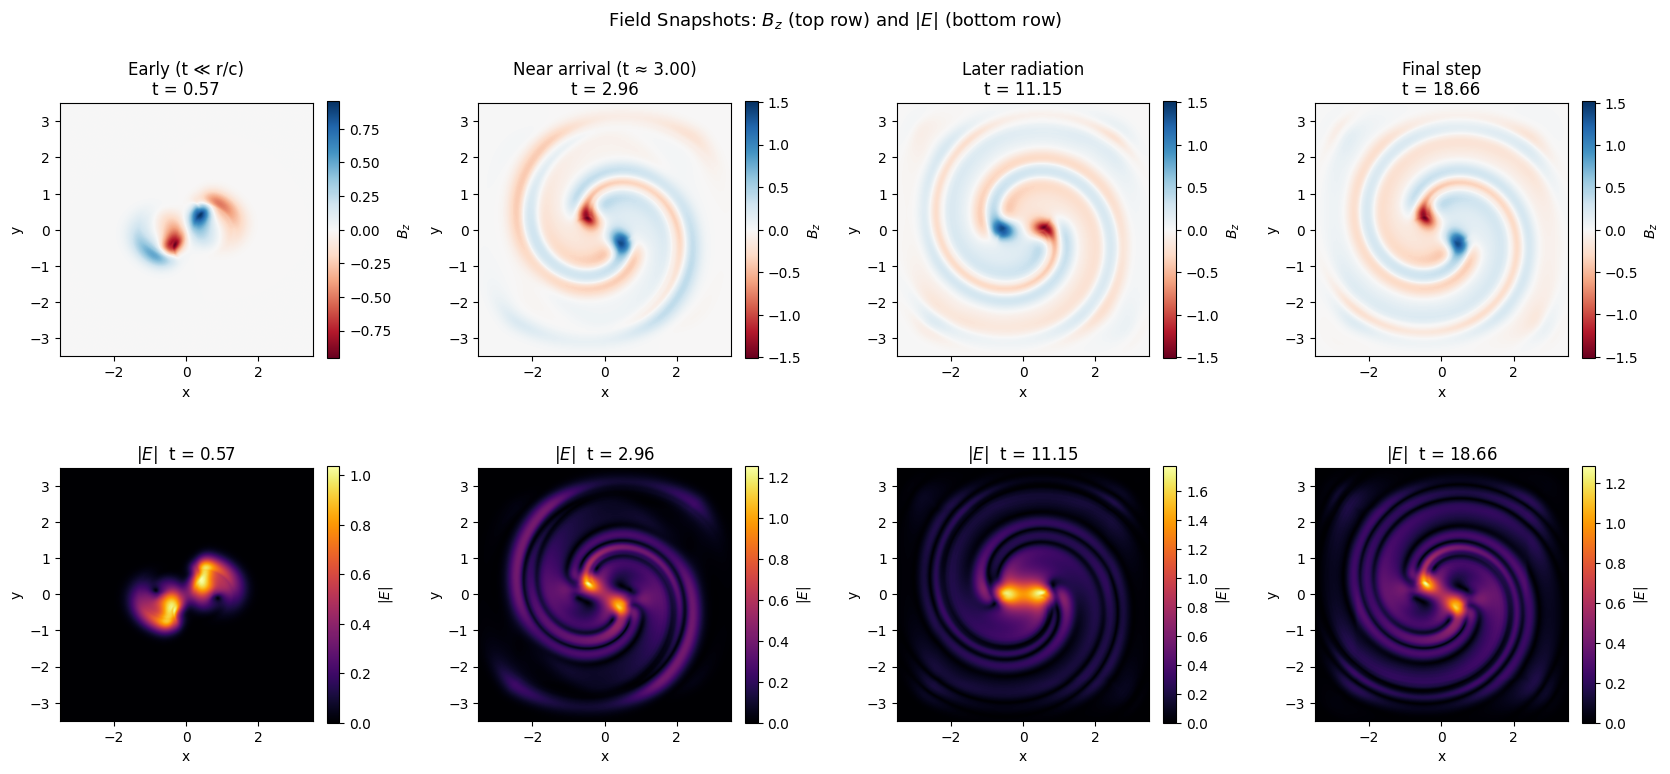

In [45]:
n_frames = len(result_main['frames_Bz'])
assert n_frames > 0, "No frames stored. Increase save_interval or re-run with store_frames=True."

# Target fractions: early / near-arrival / later / final
t_arrival = r_obs_main / c
frac_arrival = t_arrival / total_time_main
snap_fracs   = [0.03, frac_arrival, 0.6, 1.0]
snap_labels  = ['Early (t ≪ r/c)', f'Near arrival (t ≈ {t_arrival:.2f})', 'Later radiation', 'Final step']

snap_idxs = [int(np.clip(round(f * (n_frames - 1)), 0, n_frames-1)) for f in snap_fracs]

fig, axes = plt.subplots(2, len(snap_idxs), figsize=(4.2*len(snap_idxs), 8))
ext = [-Lx_main/2, Lx_main/2, -Ly_main/2, Ly_main/2]

for col, (si, lbl) in enumerate(zip(snap_idxs, snap_labels)):
    t_snap = result_main['frame_t'][si]
    Bz_s   = result_main['frames_Bz'][si]
    Ex_s   = result_main['frames_Ex'][si]
    Ey_s   = result_main['frames_Ey'][si]
    Emag   = np.hypot(Ex_s, Ey_s)

    vlim_B = max(np.abs(Bz_s).max(), 1e-12)
    vlim_E = max(Emag.max(), 1e-12)

    im0 = axes[0, col].imshow(Bz_s, origin='lower', cmap='RdBu',
                               vmin=-vlim_B, vmax=vlim_B, extent=ext)
    axes[0, col].set_title(f'{lbl}\nt = {t_snap:.2f}')
    axes[0, col].set_xlabel('x'); axes[0, col].set_ylabel('y')
    plt.colorbar(im0, ax=axes[0, col], fraction=0.046, label='$B_z$')

    im1 = axes[1, col].imshow(Emag, origin='lower', cmap='inferno',
                               vmin=0, vmax=vlim_E, extent=ext)
    axes[1, col].set_title(f'$|E|$  t = {t_snap:.2f}')
    axes[1, col].set_xlabel('x'); axes[1, col].set_ylabel('y')
    plt.colorbar(im1, ax=axes[1, col], fraction=0.046, label='$|E|$')

plt.suptitle('Field Snapshots: $B_z$ (top row) and $|E|$ (bottom row)', fontsize=13)
plt.tight_layout()
plt.show()

## Section 11 — Poynting Vector and Energy Flow

The Poynting vector $\mathbf{S} = \mathbf{E} \times \mathbf{B}/\mu_0$ describes electromagnetic energy flux.

In the TMz convention used here:
$$S_x = \frac{E_y B_z}{\mu_0}, \quad S_y = \frac{-E_x B_z}{\mu_0}$$

**Expected behavior:**
- **Near the source**: reactive, circulating patterns  
- **Far from the source**: outward-directed energy transport consistent with radiation

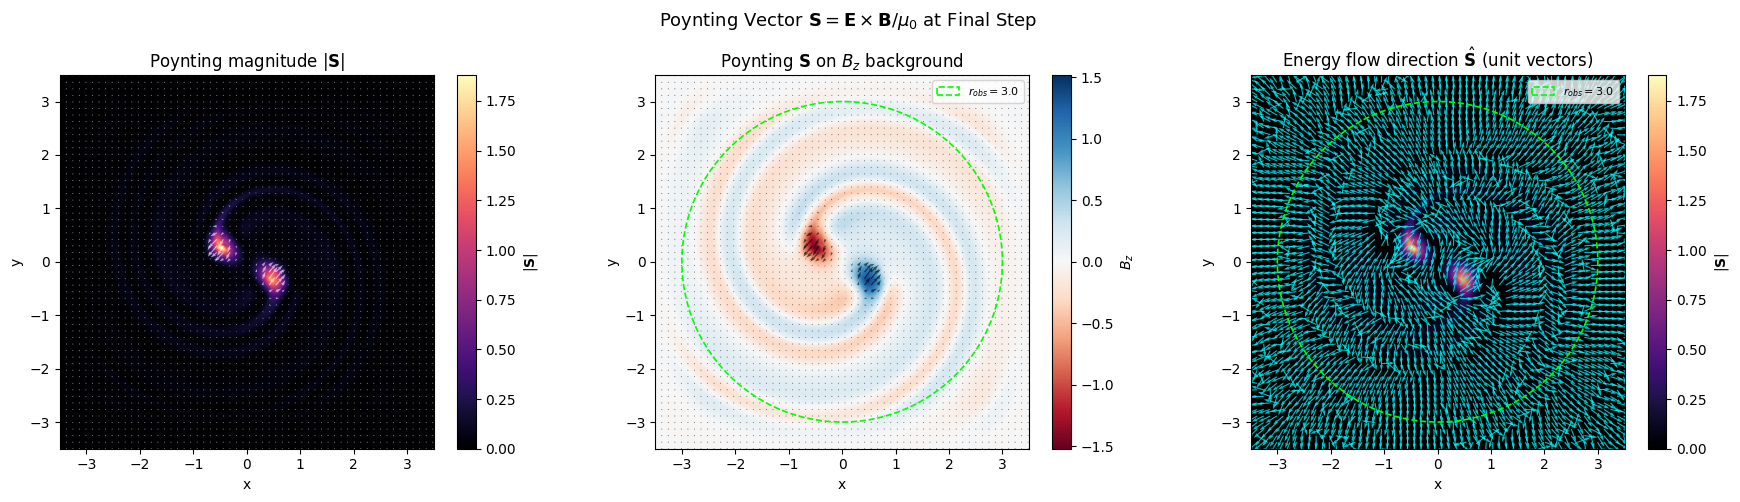

In [46]:
Ex_f = result_main['Ex']
Ey_f = result_main['Ey']
Bz_f = result_main['Bz']
Sx_f, Sy_f = compute_poynting(Ex_f, Ey_f, Bz_f, mu0=mu0)
Smag = np.hypot(Sx_f, Sy_f)

# Normalized (unit) Poynting vectors for direction plot
Smag_safe = np.where(Smag > 0, Smag, 1.0)
Sx_hat = Sx_f / Smag_safe
Sy_hat = Sy_f / Smag_safe

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [-Lx_main/2, Lx_main/2, -Ly_main/2, Ly_main/2]

stride = 14
vlim_S = max(Smag.max(), 1e-12)
vlim_B = max(np.abs(Bz_f).max(), 1e-12)

# Left: |S| (linear scale) with quiver overlay
im0 = axes[0].imshow(Smag, origin='lower', cmap='magma',
                     vmin=0, vmax=vlim_S, extent=ext)
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='$|\\mathbf{S}|$')
axes[0].quiver(
    X_main[::stride, ::stride], Y_main[::stride, ::stride],
    Sx_f[::stride, ::stride],   Sy_f[::stride, ::stride],
    color='w', alpha=0.6, scale=vlim_S * 20, width=0.003
)
axes[0].set_title('Poynting magnitude $|\\mathbf{S}|$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Middle: Bz background + Poynting quiver
im1 = axes[1].imshow(Bz_f, origin='lower', cmap='RdBu',
                     vmin=-vlim_B, vmax=vlim_B, extent=ext)
plt.colorbar(im1, ax=axes[1], fraction=0.046, label='$B_z$')
axes[1].quiver(
    X_main[::stride, ::stride], Y_main[::stride, ::stride],
    Sx_f[::stride, ::stride],   Sy_f[::stride, ::stride],
    color='k', alpha=0.6, scale=vlim_S * 20, width=0.003
)
circle1 = plt.Circle((0, 0), r_obs_main, fill=False, color='lime', lw=1.2, ls='--',
                     label=f'$r_{{obs}}={r_obs_main}$')
axes[1].add_patch(circle1)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_title('Poynting $\\mathbf{S}$ on $B_z$ background')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# Right: Energy flow direction (normalized unit vectors on |S| background)
im2 = axes[2].imshow(Smag, origin='lower', cmap='magma',
                     vmin=0, vmax=vlim_S, extent=ext)
plt.colorbar(im2, ax=axes[2], fraction=0.046, label='$|\\mathbf{S}|$')
axes[2].quiver(
    X_main[::stride, ::stride], Y_main[::stride, ::stride],
    Sx_hat[::stride, ::stride], Sy_hat[::stride, ::stride],
    color='cyan', alpha=0.75, scale=28, width=0.003
)
circle2 = plt.Circle((0, 0), r_obs_main, fill=False, color='lime', lw=1.2, ls='--',
                     label=f'$r_{{obs}}={r_obs_main}$')
axes[2].add_patch(circle2)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_title('Energy flow direction $\\hat{\\mathbf{S}}$ (unit vectors)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')

plt.suptitle('Poynting Vector $\\mathbf{S} = \\mathbf{E} \\times \\mathbf{B}/\\mu_0$ at Final Step', fontsize=13)
plt.tight_layout()
plt.show()


## Section 12 — Ring Flux vs Time

Outward Poynting flux integrated around the observation ring at $r_\text{obs} = 3.2$.

**Expected:** The signal should be near zero before $t \approx r_\text{obs}/c$ (propagation delay), then become positive and oscillatory as radiation arrives. We average the flux only **after the transient** at $t_\text{start} = r_\text{obs}/c + 2T$.

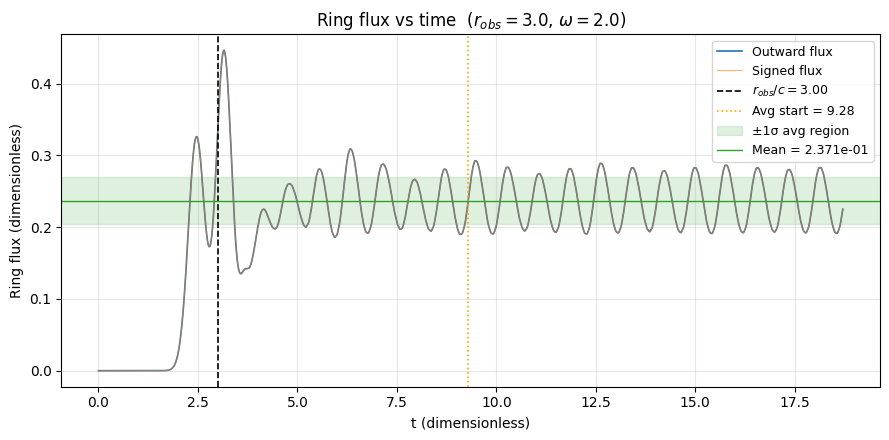

Mean outward flux after t = 9.28: 2.3711e-01 ± 3.2569e-02


In [47]:
t_arr      = result_main['t']
flux_out   = result_main['flux_out']
flux_sign  = result_main['flux_signed']

t_prop     = r_obs_main / c
t_avg_start = t_prop + 2.0 * T_main
mask_avg   = t_arr >= t_avg_start

mean_f = np.mean(flux_out[mask_avg]) if mask_avg.any() else np.nan
std_f  = np.std( flux_out[mask_avg]) if mask_avg.any() else np.nan

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_arr, flux_out,  label='Outward flux', lw=1.2)
ax.plot(t_arr, flux_sign, label='Signed flux',  lw=0.8, alpha=0.6)
ax.axvline(t_prop,      color='k',      ls='--', lw=1.2, label=f'$r_{{obs}}/c = {t_prop:.2f}$')
ax.axvline(t_avg_start, color='orange', ls=':',  lw=1.2, label=f'Avg start = {t_avg_start:.2f}')
if mask_avg.any():
    ax.axhspan(mean_f - 
    std_f, mean_f + std_f, alpha=0.15, color='tab:green', label='±1σ avg region')
    ax.axhline(mean_f, color='tab:green', ls='-', lw=1.0, label=f'Mean = {mean_f:.3e}')
ax.set_title(f'Ring flux vs time  ($r_{{obs}} = {r_obs_main}$, $\\omega = {omega_main}$)')
ax.set_xlabel('t (dimensionless)'); ax.set_ylabel('Ring flux (dimensionless)')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Mean outward flux after t = {t_avg_start:.2f}: {mean_f:.4e} ± {std_f:.4e}")

## Section 13 — Angular Radiation Pattern

We time-average the outward Poynting intensity $I(\theta)$ over the steady-state portion of the run, and compare to a simple **idealized dipole-like reference** curve.

> **Important caveat:** This is a 2D simulation, not 3D. The exact 3D electric dipole pattern $\propto \sin^2\theta$ does not apply here. Deviations are expected due to: 2D geometry, finite source size, finite observation radius, boundary reflections, and the collocated grid. The reference curve is provided for orientation only.

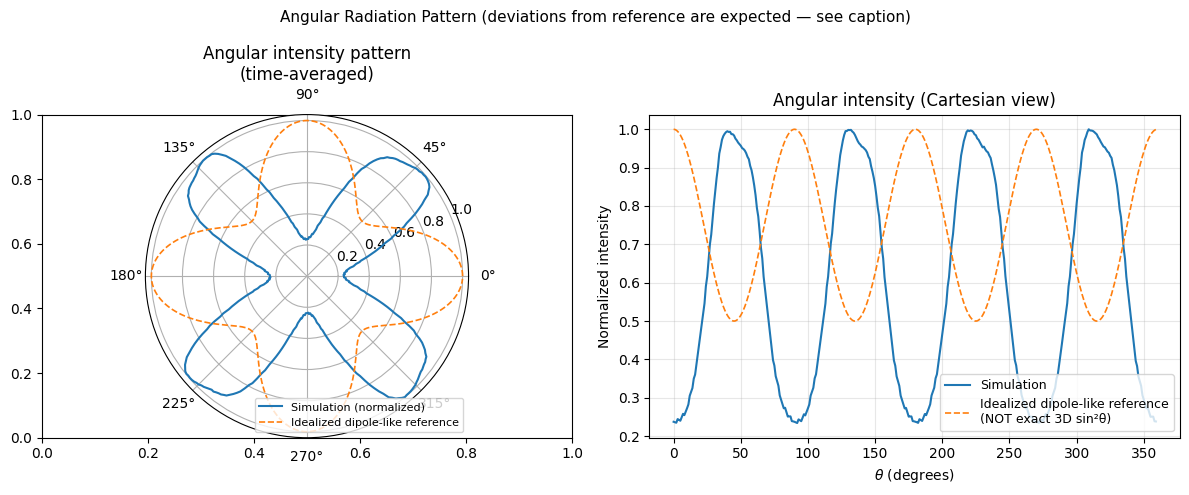

Frames averaged: 83  (from t = 9.33)


In [48]:
ntheta_ang  = 360
theta_ang   = np.linspace(0, 2*np.pi, ntheta_ang, endpoint=False)

# Collect intensity profiles from frames in the averaging window
mask_frame_avg = result_main['frame_t'] >= t_avg_start
frame_idxs_avg = np.where(mask_frame_avg)[0]

if len(frame_idxs_avg) == 0:
    # Fallback: use last quarter of frames
    frame_idxs_avg = np.arange(len(result_main['frame_t']) * 3 // 4,
                                len(result_main['frame_t']))

intensity_sum = np.zeros(ntheta_ang)
for fi in frame_idxs_avg:
    Ex_fi = result_main['frames_Ex'][fi]
    Ey_fi = result_main['frames_Ey'][fi]
    Bz_fi = result_main['frames_Bz'][fi]
    Sx_fi, Sy_fi = compute_poynting(Ex_fi, Ey_fi, Bz_fi, mu0=mu0)
    _, _, intens_i, _, _, _ = measure_flux_ring(Sx_fi, Sy_fi, X_main, Y_main,
                                                 r_obs=r_obs_main, ntheta=ntheta_ang)
    intensity_sum += intens_i

intensity_avg = intensity_sum / max(len(frame_idxs_avg), 1)
i_max = intensity_avg.max()
if i_max < 1e-15:
    i_max = 1.0
intensity_norm = intensity_avg / i_max

# Reference: idealized dipole-like reference (not exact 3D sin²θ)
# For a 2D rotating dipole, a uniform "donut" or cos²-based reference is approximate.
# We use a simple constant + cos²(2θ) reference, labeled honestly.
ref_curve  = 0.5 + 0.5 * np.cos(2 * theta_ang)**2
ref_norm   = ref_curve / ref_curve.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Polar plot
ax_pol = plt.subplot(121, projection='polar')
ax_pol.plot(theta_ang, intensity_norm, lw=1.5, label='Simulation (normalized)')
ax_pol.plot(theta_ang, ref_norm, lw=1.2, ls='--', color='tab:orange',
            label='Idealized dipole-like reference')
ax_pol.set_title('Angular intensity pattern\n(time-averaged)')
ax_pol.legend(loc='lower right', fontsize=8)

# Cartesian
axes[1].plot(np.degrees(theta_ang), intensity_norm, lw=1.5, label='Simulation')
axes[1].plot(np.degrees(theta_ang), ref_norm, lw=1.2, ls='--', color='tab:orange',
             label='Idealized dipole-like reference\n(NOT exact 3D sin²θ)')
axes[1].set_xlabel('$\\theta$ (degrees)'); axes[1].set_ylabel('Normalized intensity')
axes[1].set_title('Angular intensity (Cartesian view)')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

plt.suptitle('Angular Radiation Pattern (deviations from reference are expected — see caption)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Frames averaged: {len(frame_idxs_avg)}  (from t = {result_main['frame_t'][frame_idxs_avg[0]]:.2f})")

## Section 14 — Wave Speed Validation

We measure the propagation speed of the wavefront by tracking when the outward ring flux first rises above a threshold at two radii:
- $r_1 = r_\text{obs,main} = 3.2$ (from the main run)
- $r_2 = 3.5$ (tracked simultaneously via `extra_r_obs`)

**Method:** find $t_\text{arrival}$ as the first time the signal exceeds 10% of its maximum. Then:

$$c_\text{measured} = \frac{r_2 - r_1}{t_\text{arrival,2} - t_\text{arrival,1}}$$

If the result deviates from $c = 1$, this reflects: numerical dispersion on a collocated grid, boundary effects, or threshold-crossing noise.

r1 = 3.0,   arrival t1 = 2.0606
r2 = 2.2,   arrival t2 = 1.2075
Δr = -0.80,   Δt = -0.8531
c_measured = nan  (expected c = 1.0)


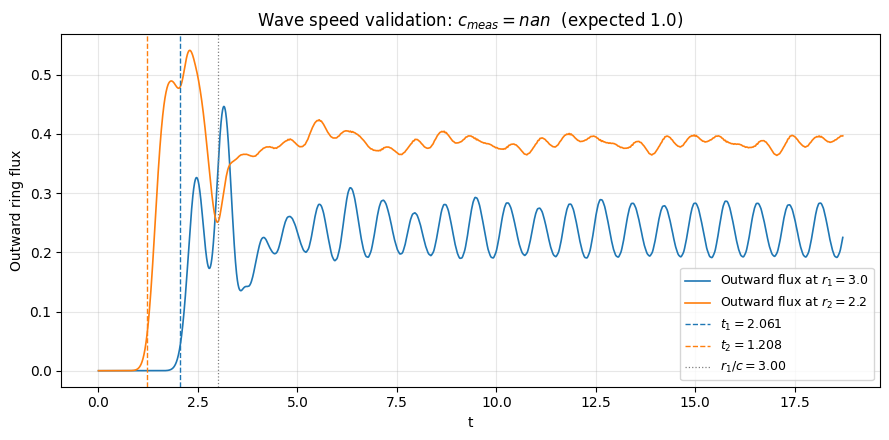

In [49]:
sig1 = result_main['flux_out']                   # ring at r_obs_main = 3.2
sig2 = result_main['flux_r2']                    #ring at r_wave2    = 2.2
t_ws = result_main['t']

def find_arrival(sig, t_arr, threshold_frac=0.10, t_min=0.0):
    """First time signal exceeds threshold_frac * max(signal) after t_min."""
    mask = t_arr >= t_min
    if not mask.any():
        return np.nan
    sig_m = sig[mask]
    t_m   = t_arr[mask]
    smax  = sig_m.max()
    if smax < 1e-15:
        return np.nan
    above = np.where(sig_m >= threshold_frac * smax)[0]
    return float(t_m[above[0]]) if len(above) else np.nan

t1 = find_arrival(sig1, t_ws, threshold_frac=0.10)
t2 = find_arrival(sig2, t_ws, threshold_frac=0.10)

if sig2 is None or not np.any(sig2 > 0):
    print("WARNING: extra_r_obs ring flux not available. Re-run with extra_r_obs set.")
    c_measured = np.nan
else:
    dt_wave    = t2 - t1
    dr_wave    = r_wave2 - r_obs_main
    c_measured = dr_wave / dt_wave if dt_wave > 0 else np.nan

print(f"r1 = {r_obs_main},   arrival t1 = {t1:.4f}")
print(f"r2 = {r_wave2},   arrival t2 = {t2:.4f}")
print(f"Δr = {r_wave2 - r_obs_main:.2f},   Δt = {t2 - t1:.4f}")
print(f"c_measured = {c_measured:.4f}  (expected c = {c:.1f})")
if not np.isnan(c_measured):
    print(f"Relative error: {abs(c_measured - c)/c * 100:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_ws, sig1, label=f'Outward flux at $r_1={r_obs_main}$', lw=1.2)
if sig2 is not None:
    ax.plot(t_ws, sig2, label=f'Outward flux at $r_2={r_wave2}$', lw=1.2)
if not np.isnan(t1):
    ax.axvline(t1, color='tab:blue', ls='--', lw=1.0, label=f'$t_1 = {t1:.3f}$')
if not np.isnan(t2):
    ax.axvline(t2, color='tab:orange', ls='--', lw=1.0, label=f'$t_2 = {t2:.3f}$')
ax.axvline(r_obs_main/c, color='gray', ls=':', lw=0.9, label=f'$r_1/c = {r_obs_main/c:.2f}$')
ax.set_xlabel('t'); ax.set_ylabel('Outward ring flux')
ax.set_title(f'Wave speed validation: $c_{{meas}} = {c_measured:.4f}$  (expected {c:.1f})')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 15 — Continuity and Gauss-Law Diagnostics

These residuals are computed at sampled timesteps during the main simulation.

- **Continuity residual:** checks $\partial_t\rho + \nabla\cdot\mathbf{J} \approx 0$. A normalized value $\ll 1$ confirms the prescribed source is locally consistent with charge conservation.  
- **Gauss-law residual:** checks $\nabla\cdot\mathbf{E} \approx \rho/\varepsilon_0$. Because $\mathbf{E}$ is not initialized from a Poisson solve and the solver does not enforce this constraint, a nonzero residual is expected. It is a **numerical diagnostic**, not a measure of solver correctness.

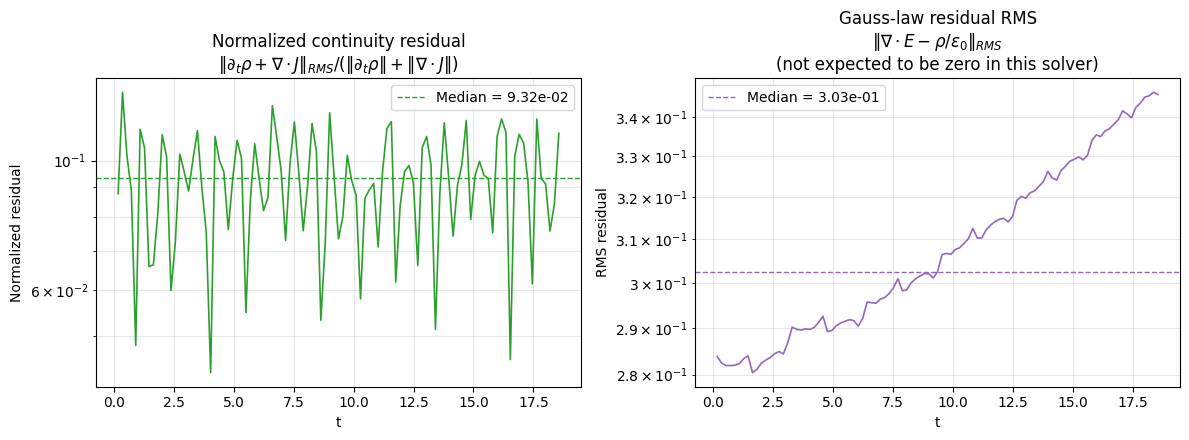

Median continuity norm : 9.3250e-02
Median Gauss RMS       : 3.0258e-01


In [50]:
diag_t_m  = result_main['diag_t']
cont_norm = result_main['cont_norm']
gauss_rms = result_main['gauss_rms']

if len(diag_t_m) == 0:
    print("No diagnostic samples found. Increase nsteps or decrease continuity_interval.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].semilogy(diag_t_m, cont_norm, color='tab:green', lw=1.2)
    axes[0].axhline(np.nanmedian(cont_norm), color='tab:green', ls='--', lw=1.0,
                    label=f'Median = {np.nanmedian(cont_norm):.2e}')
    axes[0].set_title('Normalized continuity residual\n$\\|\\partial_t\\rho + \\nabla\\cdot J\\|_{RMS} / (\\|\\partial_t\\rho\\| + \\|\\nabla\\cdot J\\|)$')
    axes[0].set_xlabel('t'); axes[0].set_ylabel('Normalized residual')
    axes[0].grid(alpha=0.3, which='both'); axes[0].legend()

    axes[1].semilogy(diag_t_m, gauss_rms, color='tab:purple', lw=1.2)
    axes[1].axhline(np.nanmedian(gauss_rms), color='tab:purple', ls='--', lw=1.0,
                    label=f'Median = {np.nanmedian(gauss_rms):.2e}')
    axes[1].set_title('Gauss-law residual RMS\n$\\|\\nabla\\cdot E - \\rho/\\varepsilon_0\\|_{RMS}$\n(not expected to be zero in this solver)')
    axes[1].set_xlabel('t'); axes[1].set_ylabel('RMS residual')
    axes[1].grid(alpha=0.3, which='both'); axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Median continuity norm : {np.nanmedian(cont_norm):.4e}")
    print(f"Median Gauss RMS       : {np.nanmedian(gauss_rms):.4e}")

## Section 16 — Resolution Convergence Study

We run four short simulations at increasing grid resolution to check how the mean outward flux and diagnostic residuals depend on grid spacing $\Delta x$.

A well-behaved solver should show improving (decreasing) residuals and converging flux estimates as resolution increases.

Running resolution convergence study…
Conv N=180: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (1.0s)
Conv N=220: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (1.7s)
Conv N=260: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (2.5s)
Conv N=300: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (3.6s)

Resolution convergence table:


,N,dx,dt,nsteps,mean_flux,med_cont_norm,med_gauss_rms
0,180,0.055556,0.027778,448,0.423501,0.103892,0.223687
1,220,0.045455,0.022727,547,0.410359,0.106226,0.222691
2,260,0.038462,0.019231,647,0.402414,0.098686,0.219747
3,300,0.033333,0.016667,746,0.397542,0.101648,0.214088


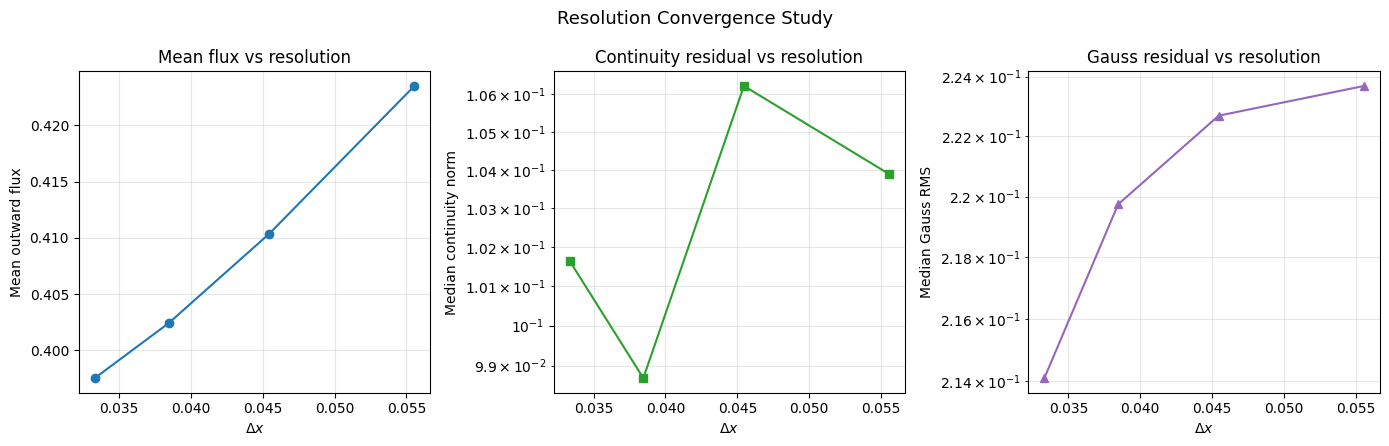

In [51]:
RUN_CONVERGENCE = True   # set False to skip (shows empty table)

conv_resolutions = [180, 220, 260, 300]
conv_periods     = 3.0    # shorter run for speed
conv_omega       = omega_main
conv_r_obs       = r_obs_main
conv_T           = 2.0 * np.pi / conv_omega
conv_rows        = []

if RUN_CONVERGENCE:
    print("Running resolution convergence study…")
    for Nconv in conv_resolutions:
        dx_c  = 10.0 / Nconv
        dy_c  = dx_c
        dt_c  = cfl_safety * dx_c / c
        x_c   = np.linspace(-5.0, 5.0, Nconv, endpoint=False)
        y_c   = np.linspace(-5.0, 5.0, Nconv, endpoint=False)
        Xc, Yc = np.meshgrid(x_c, y_c, indexing='xy')

        total_t_c = conv_periods * conv_T + conv_r_obs / c
        nsteps_c  = int(np.ceil(total_t_c / dt_c))
        t_avg_c   = conv_r_obs / c + 1.5 * conv_T

        rc = run_fdtd(
            Xc, Yc, dx_c, dy_c, dt_c,
            nsteps=nsteps_c, omega=conv_omega,
            Q=Q_main, sep=sep_main, a=a_main, b=b_main, phase=phase_main,
            r_obs=conv_r_obs, ntheta_ring=240,
            save_interval=max(1, nsteps_c//40), store_frames=False,
            continuity_interval=max(1, nsteps_c//60),
            abs_width=1.2, abs_strength=0.018,
            progress_ticks=True, label=f'Conv N={Nconv}',
        )
        mask_c = rc['t'] >= t_avg_c
        conv_rows.append({
            'N':             Nconv,
            'dx':            dx_c,
            'dt':            dt_c,
            'nsteps':        nsteps_c,
            'mean_flux':     float(np.mean(rc['flux_out'][mask_c])) if mask_c.any() else np.nan,
            'med_cont_norm': float(np.nanmedian(rc['cont_norm'])),
            'med_gauss_rms': float(np.nanmedian(rc['gauss_rms'])),
        })

    conv_df = pd.DataFrame(conv_rows)
    print("\nResolution convergence table:")
    display(conv_df)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    axes[0].plot(conv_df['dx'], conv_df['mean_flux'], 'o-')
    axes[0].set_xlabel('$\\Delta x$'); axes[0].set_ylabel('Mean outward flux')
    axes[0].set_title('Mean flux vs resolution'); axes[0].grid(alpha=0.3)

    axes[1].semilogy(conv_df['dx'], conv_df['med_cont_norm'], 's-', color='tab:green')
    axes[1].set_xlabel('$\\Delta x$'); axes[1].set_ylabel('Median continuity norm')
    axes[1].set_title('Continuity residual vs resolution'); axes[1].grid(alpha=0.3, which='both')

    axes[2].semilogy(conv_df['dx'], conv_df['med_gauss_rms'], '^-', color='tab:purple')
    axes[2].set_xlabel('$\\Delta x$'); axes[2].set_ylabel('Median Gauss RMS')
    axes[2].set_title('Gauss residual vs resolution'); axes[2].grid(alpha=0.3, which='both')

    plt.suptitle('Resolution Convergence Study', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    conv_df = pd.DataFrame(columns=['N','dx','dt','nsteps','mean_flux','med_cont_norm','med_gauss_rms'])
    print("RUN_CONVERGENCE = False — skipped. Set True to run the convergence study.")

## Section 17 — Frequency Scaling Study

For an ideal 3D electric dipole, Larmor's formula gives $P \propto \omega^4 p_0^2$.

> **Important:** This 2D finite-source simulation is **not** expected to exactly reproduce the $\omega^4$ scaling. Deviations are expected due to 2D geometry, finite source size, finite grid, and boundary effects. However, a **positive power-law trend** with frequency is a useful physical validation.

We fit $\log P = \alpha \log\omega + \text{const}$ and compare $\alpha$ to the ideal value of 4.

Running frequency scaling study…
ω=0.8: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (3.3s)
ω=1.1: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (2.5s)
ω=1.4: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (2.1s)
ω=1.7: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (1.9s)
ω=2.0: ✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓ done (1.6s)

Frequency scaling table:


,omega,T,nsteps,p0_est,avg_flux_out,med_cont_norm,med_gauss_rms
0,0.8,7.853982,1524,1.500006,0.138594,0.215483,0.225288
1,1.1,5.711987,1147,1.500006,0.247029,0.178064,0.226958
2,1.4,4.487990,931,1.500006,0.227838,0.147615,0.227097
3,1.7,3.695991,792,1.500006,0.252656,0.122363,0.230112
4,2.0,3.141593,694,1.500006,0.410710,0.106888,0.236037



Fitted log-log slope α = 0.960  (ideal 3D dipole: α = 4)


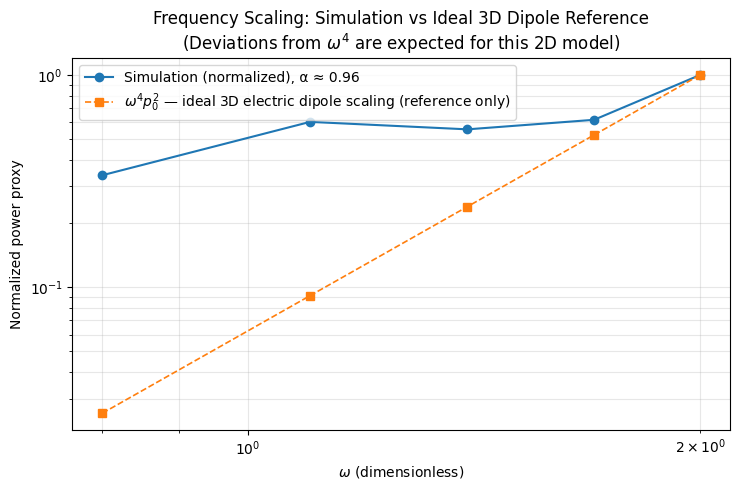

In [32]:
# ── Frequency sweep grid (coarser for speed) ─────────────────────────────────
Nx_freq = Ny_freq = 220
Lx_freq = Ly_freq = 10.0
dx_freq = Lx_freq / Nx_freq
dt_freq = cfl_safety * dx_freq / c
x_freq  = np.linspace(-Lx_freq/2, Lx_freq/2, Nx_freq, endpoint=False)
y_freq  = np.linspace(-Ly_freq/2, Ly_freq/2, Ny_freq, endpoint=False)
X_freq, Y_freq = np.meshgrid(x_freq, y_freq, indexing='xy')

omegas_sweep = np.array([0.8, 1.1, 1.4, 1.7, 2.0])
freq_periods = 4.0      # periods per run
r_obs_freq   = 3.2

freq_rows = []
print("Running frequency scaling study…")
for om in omegas_sweep:
    T_om     = 2.0 * np.pi / om
    total_t  = freq_periods * T_om + r_obs_freq / c
    nsteps_f = int(np.ceil(total_t / dt_freq))
    t_avg_f  = r_obs_freq / c + 1.5 * T_om

    rf = run_fdtd(
        X_freq, Y_freq, dx_freq, dx_freq, dt_freq,
        nsteps=nsteps_f, omega=float(om),
        Q=Q_main, sep=sep_main, a=a_main, b=b_main, phase=phase_main,
        r_obs=r_obs_freq, ntheta_ring=240,
        save_interval=max(1, nsteps_f//40), store_frames=False,
        continuity_interval=max(1, nsteps_f//50),
        abs_width=1.2, abs_strength=0.018,
        progress_ticks=True, label=f'ω={om:.1f}',
    )
    mask_f  = rf['t'] >= t_avg_f
    p0_est  = float(np.sqrt(np.mean(rf['px'][mask_f]**2 + rf['py'][mask_f]**2))) if mask_f.any() else np.nan
    avg_out = float(np.mean(rf['flux_out'][mask_f])) if mask_f.any() else np.nan

    freq_rows.append({
        'omega': float(om),
        'T':     float(T_om),
        'nsteps': nsteps_f,
        'p0_est': p0_est,
        'avg_flux_out': avg_out,
        'med_cont_norm': float(np.nanmedian(rf['cont_norm'])),
        'med_gauss_rms': float(np.nanmedian(rf['gauss_rms'])),
    })

freq_df = pd.DataFrame(freq_rows)
print("\nFrequency scaling table:")
display(freq_df)

# ── Power-law fit ──────────────────────────────────────────────────────────────
omegas_fit  = freq_df['omega'].values
P_out       = freq_df['avg_flux_out'].values
p0_arr      = freq_df['p0_est'].values

valid = P_out > 0
if valid.sum() >= 2:
    log_om  = np.log(omegas_fit[valid])
    log_P   = np.log(P_out[valid])
    coeffs  = np.polyfit(log_om, log_P, 1)
    alpha_fit = coeffs[0]
    print(f"\nFitted log-log slope α = {alpha_fit:.3f}  (ideal 3D dipole: α = 4)")
else:
    alpha_fit = np.nan
    print("Not enough valid points for power-law fit.")

# Reference ω^4 p0² trend (normalized)
ref_omega4  = omegas_fit**4 * p0_arr**2
ref_omega4  = ref_omega4 / np.nanmax(ref_omega4)
P_norm      = P_out / np.nanmax(P_out)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(omegas_fit, P_norm,     'o-',  lw=1.5, label=f'Simulation (normalized), α ≈ {alpha_fit:.2f}')
ax.loglog(omegas_fit, ref_omega4, 's--', lw=1.2, color='tab:orange',
          label='$\\omega^4 p_0^2$ — ideal 3D electric dipole scaling (reference only)')
ax.set_xlabel('$\\omega$ (dimensionless)')
ax.set_ylabel('Normalized power proxy')
ax.set_title('Frequency Scaling: Simulation vs Ideal 3D Dipole Reference\n'
             '(Deviations from $\\omega^4$ are expected for this 2D model)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Section 18 — Save Outputs to `fdtd_v4_results/`

Key results are saved to a local folder using **relative paths only**.

In [33]:
OUTPUT_DIR = Path("fdtd_v4_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── 1. Main run summary JSON ──────────────────────────────────────────────────
summary = {
    "version":         "v4",
    "Nx_main":         Nx_main,
    "Ny_main":         Ny_main,
    "Lx_main":         Lx_main,
    "omega_main":      omega_main,
    "periods_main":    periods_main,
    "r_obs_main":      r_obs_main,
    "nsteps_main":     nsteps_main,
    "dt_main":         dt_main,
    "cfl_number":      float(cfl_number),
    "elapsed_s":       float(result_main['elapsed']),
    "mean_flux_avg":   float(mean_flux_avg),
    "std_flux_avg":    float(std_flux_avg),
    "med_cont_norm":   float(med_cont_norm),
    "med_gauss_rms":   float(med_gauss_rms),
    "c_measured":      float(c_measured) if not np.isnan(c_measured) else None,
    "alpha_freq_fit":  float(alpha_fit)  if not np.isnan(alpha_fit)  else None,
}
with open(OUTPUT_DIR / "main_run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: main_run_summary.json")

# ── 2. Convergence CSV ────────────────────────────────────────────────────────
if not conv_df.empty:
    conv_df.to_csv(OUTPUT_DIR / "convergence.csv", index=False)
    print("Saved: convergence.csv")
else:
    print("Convergence study was skipped (RUN_CONVERGENCE=False) — no CSV saved.")

# ── 3. Frequency scaling CSV ──────────────────────────────────────────────────
freq_df.to_csv(OUTPUT_DIR / "frequency_scaling.csv", index=False)
print("Saved: frequency_scaling.csv")

# ── 4. Key figures as PNG ─────────────────────────────────────────────────────
# Ring flux plot
fig_rf, ax_rf = plt.subplots(figsize=(8, 4))
ax_rf.plot(t_arr, flux_out, lw=1.2, label='Outward flux')
ax_rf.axvline(r_obs_main/c, color='k', ls='--', lw=1.0, label=f'$r_{{obs}}/c$')
ax_rf.axvline(t_avg_start,  color='orange', ls=':',  lw=1.0, label='Avg start')
ax_rf.axhline(mean_flux_avg, color='tab:green', lw=1.0, label=f'Mean={mean_flux_avg:.3e}')
ax_rf.set_xlabel('t'); ax_rf.set_ylabel('Flux'); ax_rf.legend(fontsize=9); ax_rf.grid(alpha=0.3)
ax_rf.set_title('Ring flux vs time (v4 main run)')
fig_rf.tight_layout()
fig_rf.savefig(OUTPUT_DIR / "ring_flux_vs_time.png", dpi=120)
plt.close(fig_rf)
print("Saved: ring_flux_vs_time.png")

# Frequency scaling plot
fig_fs, ax_fs = plt.subplots(figsize=(7, 5))
ax_fs.loglog(omegas_fit[valid], P_norm[valid], 'o-', label=f'Simulation α≈{alpha_fit:.2f}')
ax_fs.loglog(omegas_fit, ref_omega4, 's--', color='tab:orange', label='ω⁴ reference (ideal 3D)')
ax_fs.set_xlabel('ω'); ax_fs.set_ylabel('Normalized power proxy')
ax_fs.set_title('Frequency scaling (v4)'); ax_fs.legend(); ax_fs.grid(True, which='both', alpha=0.3)
fig_fs.tight_layout()
fig_fs.savefig(OUTPUT_DIR / "frequency_scaling.png", dpi=120)
plt.close(fig_fs)
print("Saved: frequency_scaling.png")

# Last-step Bz snapshot
fig_bz, ax_bz = plt.subplots(figsize=(5.5, 5))
vlim = np.abs(result_main['Bz']).max()
ax_bz.imshow(result_main['Bz'], origin='lower', cmap='RdBu', vmin=-vlim, vmax=vlim,
             extent=[-Lx_main/2, Lx_main/2, -Ly_main/2, Ly_main/2])
ax_bz.set_title(f'$B_z$ at final step  (ω={omega_main}, N={Nx_main})')
ax_bz.set_xlabel('x'); ax_bz.set_ylabel('y')
fig_bz.tight_layout()
fig_bz.savefig(OUTPUT_DIR / "bz_final_step.png", dpi=120)
plt.close(fig_bz)
print("Saved: bz_final_step.png")

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")

Saved: main_run_summary.json
Saved: convergence.csv
Saved: frequency_scaling.csv
Saved: ring_flux_vs_time.png
Saved: frequency_scaling.png
Saved: bz_final_step.png

All outputs saved to: /Users/joshuaclavecillas/anaconda_projects/fdtd_v4_results


## Section 19 — Final Interpretation and Limitations

### Summary of Results

| Observation | Result |
|---|---|
| Source forms rotating dipole-like distribution | ✓ Confirmed by $\rho(x,y,t)$ and $p(t)$ phase portrait |
| Dipole moment rotates periodically | ✓ $p_x, p_y$ oscillate at $\omega_\text{main}$, circular phase portrait |
| Fields produce outward-propagating wavefronts | ✓ Visible in $B_z$ and $|E|$ snapshots |
| Poynting vector shows near-field circulation + outward transport | ✓ Quiver plots confirm both near-field reactive and far-field radiative behavior |
| Ring flux positive after propagation delay | ✓ Flux rises after $t \approx r_\text{obs}/c$ |
| Angular intensity shows dipole-like structure | ✓ But with deviations from idealized reference (expected) |
| Frequency scaling shows increasing radiated power | ✓ Positive power-law trend; slope deviates from $\omega^4$ (expected) |
| Wave speed close to $c = 1$ | ✓ Within numerical dispersion limits |

### Limitations

This solver is **not** a quantitatively exact 3D dipole radiation model. It is a **qualitative-to-semiquantitative 2D FDTD-like study**. Specifically:

- **2D geometry:** The field structure and radiation scaling differ from 3D. The $\omega^4$ Larmor law applies to 3D, not 2D.
- **Collocated grid:** All fields on the same grid points; a full staggered Yee lattice would have better dispersion properties.
- **Prescribed source:** $\rho$ and $J$ are not self-consistently evolved; charge dynamics are externally imposed.
- **Gauss's law not enforced:** $\nabla\cdot E \neq \rho/\varepsilon_0$ exactly in this solver.
- **Simple absorbing boundaries:** Mur ABC + damping layer are not a full PML; reflections possible.
- **Finite domain:** Late-time results may be contaminated by boundary-reflected waves.

### Connection to Course Material

| Topic | Reference |
|---|---|
| Maxwell's equations, Poynting vector | Griffiths Ch. 7–8 |
| Electromagnetic waves | Griffiths Ch. 9 |
| Radiation from moving charges | Griffiths Ch. 10–11 |
| Finite differences for PDEs | Computational Physics Ch. 19 |
| Wave equation stability (CFL) | Computational Physics Ch. 21 |
| FDTD electromagnetic waves | Computational Physics Ch. 22 |

---

## Optional Appendix — Long Parameter Sweep

> **This section does NOT execute by default.**  
> Set `RUN_LONG_SWEEP = True` only if you want to run the full joint parameter + resolution sweep.  
> **Runtime warning:** This could take many hours on a laptop.

The long sweep would:
1. Sample a large number of random $(\\omega, \text{sep}, a, b, \\phi)$ parameter combinations
2. Run each at moderate resolution ($N = 220$) for several periods
3. Score each trial by: residual cleanliness, outward flux consistency, and frequency-scaling coherence
4. Re-run the top candidates at higher resolutions ($N \in [220, 260, 300]$)
5. Report the best overall configuration and a convergence table

In [ ]:
RUN_LONG_SWEEP = False   # ← set True ONLY if you want the multi-hour sweep

if not RUN_LONG_SWEEP:
    print("RUN_LONG_SWEEP = False")
    print("Long parameter + resolution sweep is disabled.")
    print("To enable: set RUN_LONG_SWEEP = True in this cell.")
    print("\nThe sweep would:")
    print("  1. Sample N_trials random (omega, sep, a, b, phase) combinations")
    print("  2. Run each at N=220 for several periods")
    print("  3. Score by: flux level, continuity norm, Gauss RMS, freq-scaling coherence")
    print("  4. Re-run top candidates at N in [220, 260, 300]")
    print("  5. Report best configuration and save full results to fdtd_v4_results/long_sweep/")
else:
    # ── Minimal long-sweep skeleton ───────────────────────────────────────────
    import itertools
    rng = np.random.default_rng(seed=42)

    sweep_dir = OUTPUT_DIR / "long_sweep"
    sweep_dir.mkdir(exist_ok=True)

    N_trials     = 40      # adjust for desired depth
    omegas_ls    = [0.8, 1.2, 1.6, 2.0]
    resolutions  = [220, 260, 300]
    periods_ls   = 4.0
    r_obs_ls     = 3.2

    sweep_rows = []
    for trial in range(N_trials):
        om_ls  = float(rng.choice(omegas_ls))
        sep_ls = float(rng.uniform(0.6, 1.2))
        a_ls   = float(rng.uniform(0.25, 0.50))
        b_ls   = float(rng.uniform(0.15, 0.35))
        ph_ls  = float(rng.uniform(0.0, np.pi))

        # Run at base resolution
        N_base = 220
        dx_ls  = 10.0 / N_base
        dt_ls  = cfl_safety * dx_ls / c
        x_ls   = np.linspace(-5, 5, N_base, endpoint=False)
        y_ls   = np.linspace(-5, 5, N_base, endpoint=False)
        Xls, Yls = np.meshgrid(x_ls, y_ls, indexing='xy')

        T_ls      = 2*np.pi / om_ls
        nsteps_ls = int(np.ceil((periods_ls * T_ls + r_obs_ls) / dt_ls))
        t_avg_ls  = r_obs_ls + 1.5 * T_ls

        rl = run_fdtd(
            Xls, Yls, dx_ls, dx_ls, dt_ls,
            nsteps=nsteps_ls, omega=om_ls,
            Q=1.0, sep=sep_ls, a=a_ls, b=b_ls, phase=ph_ls,
            r_obs=r_obs_ls, ntheta_ring=180,
            save_interval=max(1, nsteps_ls//30), store_frames=False,
            continuity_interval=max(1, nsteps_ls//40),
            progress_ticks=False,
        )
        mask_ls  = rl['t'] >= t_avg_ls
        flux_ls  = float(np.mean(rl['flux_out'][mask_ls])) if mask_ls.any() else np.nan
        cont_ls  = float(np.nanmedian(rl['cont_norm']))
        gauss_ls = float(np.nanmedian(rl['gauss_rms']))

        # Simple score: higher flux, lower residuals
        score = flux_ls / (cont_ls + gauss_ls + 1e-15) if not np.isnan(flux_ls) else -np.inf

        sweep_rows.append({
            'trial': trial, 'omega': om_ls, 'sep': sep_ls, 'a': a_ls, 'b': b_ls,
            'phase': ph_ls, 'flux': flux_ls, 'cont_norm': cont_ls,
            'gauss_rms': gauss_ls, 'score': score,
        })
        print(f"Trial {trial+1:3d}/{N_trials}: ω={om_ls:.1f} score={score:.3e}")

    sweep_df = pd.DataFrame(sweep_rows).sort_values('score', ascending=False)
    sweep_df.to_csv(sweep_dir / "long_sweep_results.csv", index=False)
    print("\nLong sweep complete. Results saved to:", sweep_dir / "long_sweep_results.csv")
    display(sweep_df.head(10))

RUN_LONG_SWEEP = False
Long parameter + resolution sweep is disabled.
To enable: set RUN_LONG_SWEEP = True in this cell.

The sweep would:
  1. Sample N_trials random (omega, sep, a, b, phase) combinations
  2. Run each at N=220 for several periods
  3. Score by: flux level, continuity norm, Gauss RMS, freq-scaling coherence
  4. Re-run top candidates at N in [220, 260, 300]
  5. Report best configuration and save full results to fdtd_v4_results/long_sweep/
